In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [7]:
df = pd.read_csv('water_potability_clean.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (3276, 10)


In [9]:
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print("Data splitting, scaling, and LDA transformation complete.")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_train_lda:    {X_train_lda.shape}")

Data splitting, scaling, and LDA transformation complete.
Shape of X_train_scaled: (2620, 9)
Shape of X_train_lda:    (2620, 1)


In [10]:
# Definišemo prostor hiperparametara koje želimo da testiramo
# n_neighbors: broj suseda koje model gleda (najvažniji parametar)
# weights: da li svi susedi imaju isti uticaj ('uniform') ili bliži imaju veći ('distance')
# metric: kako se računa razdaljina
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'manhattan']
}

# --- 1. GridSearchCV na ORIGINALNIM obeležjima ---
print("--- Hyperparameter Tuning for k-NN on Original Features ---")
grid_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1) # n_jobs=-1 koristi sve CPU jezgre
grid_original.fit(X_train_scaled, y_train)

print(f"Best parameters for original features: {grid_original.best_params_}")
print(f"Best cross-validation accuracy: {grid_original.best_score_:.4f}")

# --- 2. GridSearchCV na LDA obeležjima ---
print("\n--- Hyperparameter Tuning for k-NN on LDA Features ---")
grid_lda = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_lda.fit(X_train_lda, y_train)

print(f"Best parameters for LDA features: {grid_lda.best_params_}")
print(f"Best cross-validation accuracy: {grid_lda.best_score_:.4f}")

--- Hyperparameter Tuning for k-NN on Original Features ---
Best parameters for original features: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best cross-validation accuracy: 0.6599

--- Hyperparameter Tuning for k-NN on LDA Features ---
Best parameters for LDA features: {'metric': 'minkowski', 'n_neighbors': 15, 'weights': 'uniform'}
Best cross-validation accuracy: 0.5912


--- Final Evaluation and Conclusion for k-NN Classifier ---
Conclusion: The model with original features performed better or equal in cross-validation.
Proceeding with the final test using the best k-NN model on original scaled features.

Final Model Details: KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')

Final Accuracy on the independent test set: 0.6265

Final Classification Report on the test set:
              precision    recall  f1-score   support

           0       0.65      0.84      0.73       400
           1       0.54      0.30      0.38       256

    accuracy                           0.63       656
   macro avg       0.59      0.57      0.56       656
weighted avg       0.61      0.63      0.60       656


Final Confusion Matrix on the test set:


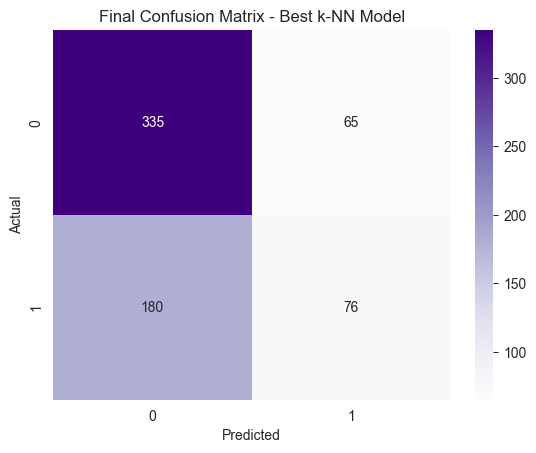

In [11]:
print("--- Final Evaluation and Conclusion for k-NN Classifier ---")

# Upoređujemo rezultate unakrsne validacije da bismo izabrali konačni model
if grid_original.best_score_ >= grid_lda.best_score_:
    print("Conclusion: The model with original features performed better or equal in cross-validation.")
    print("Proceeding with the final test using the best k-NN model on original scaled features.")

    # Preuzimamo najbolji model sa originalnim podacima
    final_model = grid_original.best_estimator_

    # Testiramo ga na finalnom test skupu
    final_predictions = final_model.predict(X_test_scaled)
    final_accuracy = accuracy_score(y_test, final_predictions)

else:
    print("Conclusion: The model with LDA-reduced features performed better in cross-validation.")
    print("Proceeding with the final test using the best k-NN model on LDA features.")

    # Preuzimamo najbolji model sa LDA podacima
    final_model = grid_lda.best_estimator_

    # Testiramo ga na finalnom test skupu
    final_predictions = final_model.predict(X_test_lda)
    final_accuracy = accuracy_score(y_test, final_predictions)

print(f"\nFinal Model Details: {final_model}")
print(f"\nFinal Accuracy on the independent test set: {final_accuracy:.4f}")

print("\nFinal Classification Report on the test set:")
print(classification_report(y_test, final_predictions))

print("\nFinal Confusion Matrix on the test set:")
cm_final = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples') # Menjamo boju radi razlikovanja
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix - Best k-NN Model')
plt.show()